# Helmholtz Equation testing


Import the necessary packages

In [28]:
# make use of QLS jupyter env
import numpy as np
import scipy as sc
from linear_solvers import NumPyLinearSolver, HHL
import time
from linear_solvers.matrices.tridiagonal_toeplitz import TridiagonalToeplitz
from linear_solvers.matrices.numpy_matrix import NumPyMatrix
from qiskit.quantum_info import Statevector
from qiskit import Aer, transpile, QuantumCircuit, execute
from qiskit.circuit.library import MCXGate
from qiskit.extensions import UnitaryGate
import math
from scipy.sparse import diags
import matplotlib.pyplot as plt
import seaborn as sns

Define Params

In [5]:
# Build the matrix A
NUM_QUBITS = 2
MATRIX_SIZE = 2 ** NUM_QUBITS

L = 1.0                                     # Domain length
N = MATRIX_SIZE                             # No. of points
h = L / (N+1)                               # Step size
k = 1.0                                     # Wavenumber (avoid k = nπ for stability!)
eps = 0.01                                # Error tolerance
x_numerical = np.linspace(0, L, N+2)[1:-1]  # Interior points


a = -2/h**2 + k**2  # main diagonal
b = 1/h**2          # off diagonal

matrix = diags([b, a, b], [-1, 0, 1], shape=(MATRIX_SIZE, MATRIX_SIZE)).toarray()

x = np.linspace(0, 1, N+2)[1:-1]  # Interior points (Dirichlet BCs)
vector = ( k**2 - np.pi**2) * np.sin(np.pi * x)  # Sinusoidal source term

print('matrix\n' , matrix)
print('vector\n', vector)
print('matrix condition number:', np.linalg.cond(matrix))

matrix
 [[-49.  25.   0.   0.]
 [ 25. -49.  25.   0.]
 [  0.  25. -49.  25.]
 [  0.   0.  25. -49.]]
vector
 [-5.21342266 -8.43549506 -8.43549506 -5.21342266]
matrix condition number: 10.463127536183748


Prepare b

C:\Users\richa\AppData\Local\Temp\ipykernel_8716\1638624058.py:4: DeprecationWarning: The method ``qiskit.circuit.quantumcircuit.QuantumCircuit.iso()`` is deprecated as of qiskit 0.46.0. It will be removed in the 1.0.0 release. Instead, append a qiskit.circuit.library.Isometry to the circuit.
  vector_circuit.isometry(


Build DST MAtrix

In [ ]:
def build_DST(dim : int) -> np.ndarray:
    """Builds the Discrete Sine Transform matrix of the given dimension."""
    DST = np.zeros((dim, dim))
    for i in range(dim):
        for j in range(dim):
            DST[i, j] = np.sqrt(2 / (dim + 1)) * np.sin((i + 1) * (j + 1) * np.pi / (dim + 1))
    return DST

def solve(matrix, vector):
    N = len(vector) # problem size
    
    # Num of system qubits + 1 ancilla
    ns = int(np.log2(N))
    qc = QuantumCircuit(ns + 1, name='NoQPE_Ancilla')

    
    # 1) State prep: amplitude encode b on system
    norm_b = np.linalg.norm(vector)
    b_normed = vector / norm_b
    qc.initialize(b_normed, range(ns))

    # Build and apply DST
    U_DST = build_DST(N)
    gate_dst = UnitaryGate(U_DST, label='DST')
    qc.append(gate_dst, list(range(ns)))
    
    # 3) ancilla-based inversion
    # We'll do a multi-controlled rotation for each index i in {0,1,2,3}.
    # We need the eigenvalues of A in the same ordering as DST.
    evals = compute_eigenvals(matrix)   # define function or do your formula
    lam_min = min(evals)
    # Choose scaling C <= lam_min so that C/lambda_i <= 1
    # e.g. let C = lam_min
    C = lam_min

    # For each i in 0..3, we do:
    #   if system == i, then rotate ancilla by angle = 2*arcsin(C/lambda_i)
    # Implementation: we must check the binary pattern of i, do X on qubits
    # with 0 in that bit, apply a CX controlling on all system qubits,
    # then revert. We'll do it in a loop:
    for i in range(N):
        # compute angle
        lam_i = evals[i]
        if lam_i == 0:
            # handle zero eigenvalue if needed, skip or raise error
            continue
        ratio = C / lam_i
        if ratio > 1:
            # This is a problem, unless you do amplitude amplification or something else.
            ratio = 1.0  # clamp for demonstration
        theta = 2*np.arcsin(ratio)   # rotation angle for R_y

        # Identify which bits are 1 vs 0 in i
        bit0 = (i >> 0) & 1
        bit1 = (i >> 1) & 1
        controls = []

        # We'll do the X-gates to flip controls for bits that are 0
        # Then do an MCX with the ancilla as target + R_y gate, 
        # but Qiskit doesn't have an 'mcry' built in older versions.
        # We can do a decomposition or use the multi-controlled toffoli + single R_y, or build a custom gate.

        # For a small system (2 qubits), we can do a quick approach:
        # if bit0 == 0, X(0)
        # if bit1 == 0, X(1)
        if bit0 == 0:
            qc.x(0)
        if bit1 == 0:
            qc.x(1)
        
        # Now qubits 0,1 are '1' if system is in state i
        # We'll implement an MCX controlling on qubits (0,1) with ancilla as target => to set ancilla=1
        # Then we do a Y-rotation on ancilla, or we do a trick with half-angle.
        # Actually, the simplest is we do an MCT (multi-controlled Toffoli) from (0,1)->ancilla,
        # then a small rotation around Y with the ancilla as the only qubit, then another MCT.
        # This is the standard building block for multi-controlled R_y:

        # Step: build a 2-controlled toffoli gate => 'ccx'
        # Qiskit has 'qc.ccx(control1, control2, target)'.

        # let's define a function that does the controlled R_y with 2 controls:
        apply_controlled_ry(qc, theta, [0,1], 2)  # qubit2 is ancilla

        # Undo X
        if bit0 == 0:
            qc.x(0)
        if bit1 == 0:
            qc.x(1)

    # 4) Undo DST
    gate_DST_dg = UnitaryGate(U_DST.conjugate().T, label='DST_dg')
    qc.append(gate_DST_dg, range(ns))

    return qc

def apply_controlled_ry(qc: QuantumCircuit, theta: float, control_qubits, target_qubit):
    """
    Implement an R_y(theta) on 'target_qubit' conditioned on all 'control_qubits'=1,
    for the special case of 2 control qubits. 
    We'll do:
      ccx(controls, target)
      ry(theta/2) on target
      ccx(controls, target)
      ry(-theta/2) on target
    This is a known decomposition for a multi-controlled R_y.
    """
    # For 2 controls, we can do:
    # 1) ccx(control1, control2, target)
    # 2) ry(theta/2, target)
    # 3) ccx(control1, control2, target)
    # 4) ry(-theta/2, target)
    qc.ccx(control_qubits[0], control_qubits[1], target_qubit)
    qc.ry(theta/2, target_qubit)
    qc.ccx(control_qubits[0], control_qubits[1], target_qubit)
    qc.ry(-theta/2, target_qubit)
def compute_eigenvals(A: np.ndarray) -> list:
    """Return the eigenvalues of A in the same ordering as the DST basis, 
    or do a direct numeric diagonalization if needed.
    Here just do a naive approach: 
    We'll do a standard numpy eig. The DST ordering might differ, 
    but let's ignore that detail for example.
    """
    w, v = np.linalg.eigh(A)
    # w is sorted in ascending order, but might not match DST ordering. For demonstration:
    return list(w)
def run_and_postselect(qc: QuantumCircuit):
    """
    Add measurement, run on statevector simulator, 
    post-select on ancilla=1, and see the system state.
    """

    # We'll add measurement of all qubits: system + ancilla
    full_qc = qc.copy()
    full_qc.measure_all()

    backend = Aer.get_backend('aer_simulator')
    result = execute(full_qc, backend, shots=2048).result()
    counts = result.get_counts(full_qc)
    # The ancilla is the last qubit measured if we measure from top to bottom or vice versa, 
    # depends on Qiskit's indexing. Let's see, by default measure_all will measure qubit0->bit0, 
    # qubit1->bit1, qubit2->bit2. 
    # If qubit2 is ancilla, then the classical bit2 is the ancilla measurement. 
    # We'll filter for bit2 = '1'.

    postselected_counts = {}
    for outcome, ccount in counts.items():
        # outcome is like '101' for qubit2qubit1qubit0 in Qiskit. 
        # We want the leftmost or rightmost bit for ancilla depending on convention. 
        # Let's assume the leftmost is qubit2. So outcome[0] is ancilla 
        # Actually let's print an example to confirm. 
        ancilla_bit = outcome[0]  # if ancilla is qubit2
        if ancilla_bit == '1':
            # keep outcome
            postselected_counts[outcome[1:]] = ccount

    # Now we can get the distribution for the system qubits only, ignoring the ancilla. 
    # We'll normalize by total shots that gave ancilla=1. 
    total_anc1 = sum(postselected_counts.values())
    system_distribution = {}
    for outcome, ccount in postselected_counts.items():
        system_distribution[outcome] = ccount / total_anc1
    
    return system_distribution
    

State index 0: quantum amp = 0.3678, classical normed = 0.3717
State index 1: quantum amp = 0.5867, classical normed = 0.6015
State index 2: quantum amp = 0.6100, classical normed = 0.6015
State index 3: quantum amp = 0.3853, classical normed = 0.3717


C:\Users\richa\AppData\Local\Temp\ipykernel_8716\2551471911.py:138: DeprecationWarning: The function ``qiskit.execute_function.execute()`` is deprecated as of qiskit 0.46.0. It will be removed in the Qiskit 1.0 release. This function combines ``transpile`` and ``backend.run``, which is covered by ``Sampler`` :mod:`~qiskit.primitives`. Alternatively, you can also run :func:`.transpile` followed by ``backend.run()``.
  result = execute(full_qc, backend, shots=2048).result()


Text(0, 0.5, 'u(x)')

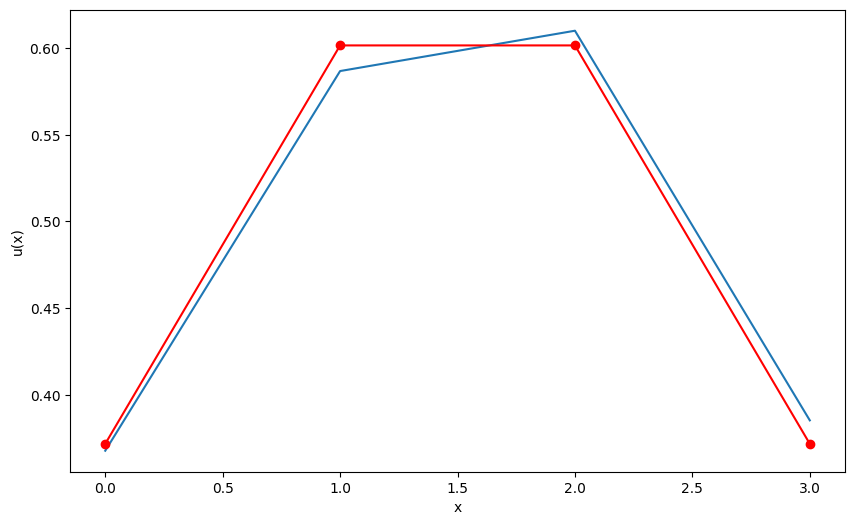

In [21]:

# 1) Build & run the circuit
qc_solution = solve(matrix, vector=vector)  # your circuit construction
system_distribution = run_and_postselect(qc_solution) # measure + post-select ancilla=1

# 2) Convert to amplitudes
p_labels = ['00','01','10','11']  # for 2 qubits, order them however your indexing is defined
p_values = [system_distribution.get(lbl, 0.0) for lbl in p_labels]
alpha = np.sqrt(p_values)

# 3) Classical solution
A_inv = np.linalg.inv(matrix)
x_classical = A_inv.dot(vector)
norm_x_classical = np.linalg.norm(x_classical)
x_classical_normed = x_classical / norm_x_classical

# 4) Compare (normalized) results
solution = []
for i, (a_i, x_i) in enumerate(zip(alpha, x_classical_normed)):
    # store
    solution.append(a_i)
    print(f"State index {i}: quantum amp = {a_i:.4f}, classical normed = {x_i:.4f}")

# 5) Plot the quantum versus numerical solution
plt.figure(figsize=(10, 6))
plt.plot(solution, label='Quantum solution')
plt.plot(x_classical_normed, 'ro-', label='Classical solution')
plt.xlabel('x')
plt.ylabel('u(x)')

### OOP implementation

In [ ]:
class DSTHHSolver:
    """
    A general no-QPE solver that:
      1) Diagonalizes matrix A (Dirichlet Helmholtz/Poisson) via DST.
      2) Uses an ancilla-based multi-controlled rotation to encode 1/lambda_i.
      3) Post-selects ancilla=1 to get x ~ A^-1 b.

    Supports n>=1 system qubits (2^n x 2^n matrix).
    """

    def __init__(self, matrix: np.ndarray, vector: np.ndarray):
        """
        Initialize with:
          matrix: NxN (2^n x 2^n) numpy array for the operator A.
          vector: length-N array for RHS b.
        """
        self.A = np.array(matrix, dtype=complex)
        self.b = np.array(vector, dtype=complex)

        # Check dimensions
        self.dim = self.A.shape[0]
        if self.dim != self.A.shape[1]:
            raise ValueError("Matrix must be square.")
        if len(self.b) != self.dim:
            raise ValueError("Matrix and vector dimension mismatch.")

        # System qubits
        self.num_sys_qubits = int(np.log2(self.dim))
        if 2**self.num_sys_qubits != self.dim:
            raise ValueError("Matrix dimension must be a power of 2.")

        # Will store the constructed circuit and distribution
        self.qc = None
        self.system_distribution = None

    def build_dst_matrix(self, dim: int) -> np.ndarray:
        """
        Build the DST-II matrix of size 'dim' x 'dim'.
        """
        DST = np.zeros((dim, dim), dtype=complex)
        factor = math.sqrt(2/(dim+1))
        for i in range(dim):
            for j in range(dim):
                DST[i, j] = factor * math.sin((i+1)*(j+1)*math.pi/(dim+1))
        return DST

    def compute_eigenvals_dirichlet(self, A: np.ndarray) -> list:
        """
        Compute eigenvalues of A. 
        (In principle, reorder them to match the DST ordering, but 
         here we do a naive np.linalg.eigh for demonstration.)
        """
        w, v = np.linalg.eigh(A)
        return list(w)

    def construct_circuit(self):
        """
        Construct the no-QPE circuit:
          - Amplitude encode b
          - Apply DST
          - Ancilla-based multi-controlled R_y for each eigenvalue
          - Undo DST
        """
        ns = self.num_sys_qubits
        # System + 1 ancilla
        qc = QuantumCircuit(ns + 1, name='NoQPE_Ancilla')

        # 1) State prep
        norm_b = np.linalg.norm(self.b)
        b_normed = self.b / norm_b
        qc.initialize(b_normed, range(ns))

        # 2) DST
        U_DST = self.build_dst_matrix(self.dim)
        gate_dst = UnitaryGate(U_DST, label='DST')
        qc.append(gate_dst, range(ns))

        # 3) Ancilla-based inversion
        evals = self.compute_eigenvals_dirichlet(self.A)
        lam_min = min(evals)
        C = lam_min

        # For each basis index i in [0..dim-1], do multi-controlled rotation
        for i in range(self.dim):
            lam_i = evals[i]
            if lam_i == 0:
                # skip or handle zero eigenvalue
                continue
            ratio = C/lam_i
            if ratio > 1.0:
                ratio = 1.0  # clamp for demonstration
            theta = 2 * math.asin(ratio)

            # Identify which qubits need X if the bit is 0
            bits = [(i >> b) & 1 for b in range(ns)]
            #  - apply X on those qubits whose bit is 0
            for qb_i, bitval in enumerate(bits):
                if bitval == 0:
                    qc.x(qb_i)

            # Multi-controlled R_y with all ns qubits as controls,
            # ancilla is the last qubit (index ns).
            # We'll use mcry(...) from Qiskit >= 0.30
            control_qubits = list(range(ns))
            target_qubit = ns
            qc.mcry(theta, control_qubits, target_qubit, None)

            # undo the X
            for qb_i, bitval in enumerate(bits):
                if bitval == 0:
                    qc.x(qb_i)

        # 4) Undo DST
        gate_dst_dg = UnitaryGate(U_DST.conjugate().T, label='DST_dg')
        qc.append(gate_dst_dg, range(ns))

        self.qc = qc
        return qc

    def run_and_postselect(self, shots=2048):
        """
        Run the circuit on the Aer simulator, measure all qubits, 
        and post-select on ancilla=1.
        Returns (system_distribution, success_prob).
        """
        if self.qc is None:
            raise ValueError("No circuit constructed. Call construct_circuit() first.")

        full_qc = self.qc.copy()
        full_qc.measure_all()

        backend = Aer.get_backend('aer_simulator')
        job = execute(full_qc, backend, shots=shots)
        result = job.result()
        counts = result.get_counts(full_qc)

        postselected_counts = {}
        for outcome, ccount in counts.items():
            # outcome = e.g. '1010' for ns+1=4 qubits, 
            # leftmost bit is qubit3 => ancilla if we do standard measure ordering.
            ancilla_bit = outcome[0]
            if ancilla_bit == '1':
                # keep system bits
                system_bits = outcome[1:]
                postselected_counts[system_bits] = postselected_counts.get(system_bits, 0) + ccount

        total_postselected = sum(postselected_counts.values())
        success_prob = total_postselected / shots if shots > 0 else 0

        if total_postselected == 0:
            return {}, success_prob

        system_distribution = {}
        for sys_str, count_val in postselected_counts.items():
            system_distribution[sys_str] = count_val / total_postselected

        return system_distribution, success_prob

    def distribution_to_solution(self, system_distribution: dict) -> np.ndarray:
        """
        Convert the post-selected system distribution to a real amplitude vector 
        (normalized). We assume the solution is real + nonnegative.
        """
        # We'll interpret e.g. '00'=index0, '01'=index1,... in little-endian style:
        def bits_to_int(bitstring):
            # bitstring left->right might be reversed relative to Qiskit qubit order.
            # We'll assume outcome[0] is qubit(ns-1), outcome[-1] is qubit0, etc.
            # But measure_all typically returns the string reversed from the usual indexing. 
            # We'll do a simple approach: reverse the string, parse binary.
            return int(bitstring[::-1], 2)

        alpha = np.zeros(self.dim, dtype=float)
        for bitstr, prob in system_distribution.items():
            i = bits_to_int(bitstr)
            alpha[i] = math.sqrt(prob)

        return alpha  # normalized up to global phase

    def solve(self, shots=2048) -> np.ndarray:
        """
        1) Build circuit
        2) Run + postselect
        3) Convert distribution -> normalized solution vector
        """
        self.construct_circuit()
        dist, success_prob = self.run_and_postselect(shots=shots)
        if not dist:
            print("No ancilla=1 events => solution is zero or scaling problem.")
            return np.zeros(self.dim)
        x_normed = self.distribution_to_solution(dist)
        return x_normed


In [41]:
# Build the matrix A
NUM_QUBITS = 3
MATRIX_SIZE = 2 ** NUM_QUBITS

L = 1.0                                     # Domain length
N = MATRIX_SIZE                             # No. of points
h = L / (N+1)                               # Step size
k = 5.0                                     # Wavenumber (avoid k = nπ for stability!)
eps = 0.01                                # Error tolerance
x_numerical = np.linspace(0, L, N+2)[1:-1]  # Interior points


a = -2/h**2 + k**2  # main diagonal
b = 1/h**2          # off diagonal

matrix = diags([b, a, b], [-1, 0, 1], shape=(MATRIX_SIZE, MATRIX_SIZE)).toarray()

x = np.linspace(0, 1, N+2)[1:-1]  # Interior points (Dirichlet BCs)
vector = ( k**2 - np.pi**2) * np.sin(np.pi * x)  # Sinusoidal source term

print('matrix condition number:', np.linalg.cond(matrix))

# Solve with the DST-based HHL solver
solver = DSTHHSolver(matrix, vector)
x_quantum = solver.solve(shots=2048)

# Normalize the classical solution
x_classical = np.linalg.solve(matrix, vector)
norm_x_classical = np.linalg.norm(x_classical)

# Compare the quantum and classical solutions
plt.figure(figsize=(10, 6))
plt.plot(x_quantum, label='Quantum solution')
plt.plot(x_classical / norm_x_classical, 'ro-', label='Classical solution')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.legend()


matrix condition number: 22.419555357285205


ValueError: math domain error